In [5]:
import pandas as pd

df = pd.read_csv("data\SampleSuperstore.csv")

print(df.head())

        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      0.00    6.871

In [6]:
sales_by_category = df.groupby("Category")["Sales"].sum()

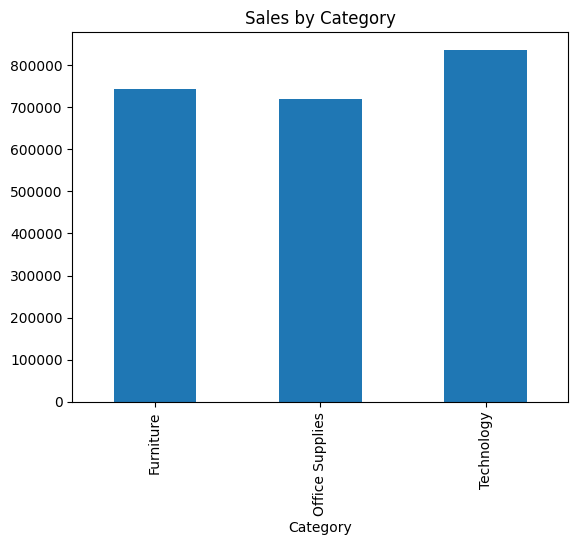

In [7]:
import matplotlib.pyplot as plt

sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.show()

---カテゴリ別集計---
                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


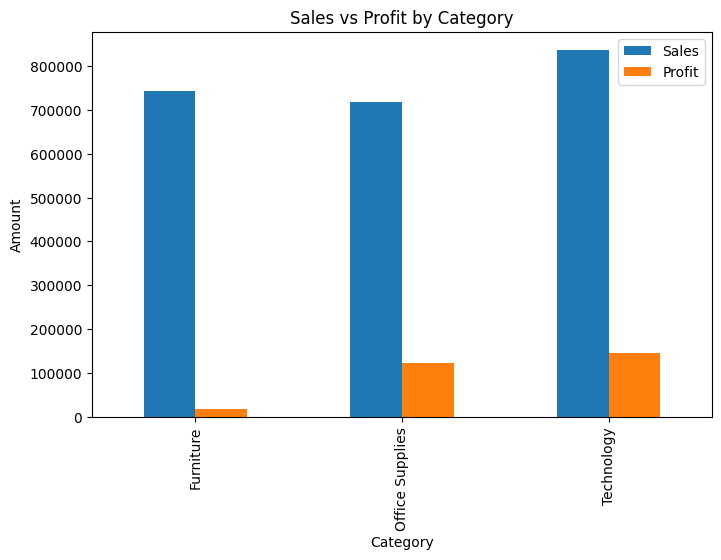


--- サブカテゴリ別利益（ワースト順）---
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

--- テーブルの地域別利益 ---
Region
Central    -3559.6504
East      -11025.3801
South      -4623.0579
West        1482.6073
Name: Profit, dtype: float64


In [9]:
# --- 1. カテゴリ別の売上と利益 ---
# まとめて合計を計算
cat_anarysis = df.groupby("Category")[["Sales", "Profit"]].sum()
print("---カテゴリ別集計---")
print(cat_anarysis)

# グラフを表示
cat_anarysis.plot(kind="bar", figsize=(8, 5))
plt.title("Sales vs Profit by Category")
plt.ylabel("Amount")
plt.show()

# --- 2. サブカテゴリ別の利益（赤字の商品の特定）---
# 利益の低い順に並べて表示
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
print("\n--- サブカテゴリ別利益（ワースト順）---")
print(sub_profit.head()) #下位の5つを表示

# --- 3. 特定の赤字商品の「地域別」状況 ---
# 例として、最も赤字な「Table（テーブル）」を地域別に集計
tables_df = df[df["Sub-Category"] == "Tables"]
region_tables = tables_df.groupby("Region")["Profit"].sum()
print("\n--- テーブルの地域別利益 ---")
print(region_tables)

In [10]:
# Excel保存用のライブラリをインポート
with pd.ExcelWriter("Salses_Anarysis_Report.xlsx") as writer:
    # 1. カテゴリ別集計を「Category_Summary」シートへ
    cat_anarysis.to_excel(writer, sheet_name="Category_Summary")

    # 2. サブカテゴリ別利益（ワースト順）を「SubCategory_Loss」シートへ
    sub_profit.to_excel(writer, sheet_name="SubCategory_Loss")

    # 3. テーブルの地域別利益を「Tables_By_Region」シートへ
    region_tables.to_excel(writer, sheet_name="Tables_By_Region")

print("Excelファイル 'Sales_Anarysis_Report' を作成しました")

Excelファイル 'Sales_Anarysis_Report' を作成しました
